In [14]:
import numpy as np
import matplotlib.pyplot as plt


Step size h = 0.1
Solution is Stable

Step size h = 0.2
Solution is Stable

Step size h = 0.3
Solution is Stable

Step size h = 0.4
Solution is Stable

Step size h = 0.5
Solution is Stable

Step size h = 1.0
Solution may not be Entirely Stable ;)


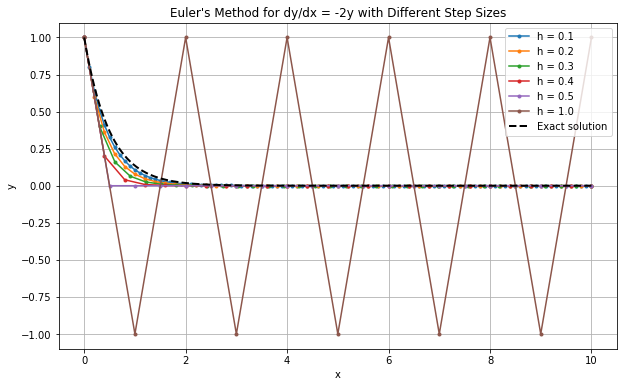

In [15]:
def f(x, y):
    return -2 * y

def exact_solution(x):
    return np.exp(-2 * x)

# Step sizes
h_values = [0.1, 0.2, 0.3, 0.4, 0.5, 1.]

# Interval from the stability challenge slide
x_start = 0
x_end = 10
y0 = 1.0
lam = -2.0

plt.figure(figsize=(10, 6))

for h in h_values:
    # Construct the Euler coefficient matrix
    A = np.array([[1 + h * lam]])   # [[1 - 2h]]

    # Compute eigenvalues with built-in function
    eigvals = np.linalg.eigvals(A)

    # Stability check
    if np.all(np.abs(eigvals) < 1):
        stability = "Solution is Stable"
    else:
        stability = "Solution may not be Entirely Stable ;)"

    # Print output
    print(f"\nStep size h = {h}")
    print(stability)

    # Simulate Euler's method
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = y0

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # Plot solution curve
    plt.plot(x_values, y_values, marker='o', markersize=3, label=f"h = {h}")

# Plot exact solution for comparison
x_exact = np.linspace(x_start, x_end, 1000)
y_exact = exact_solution(x_exact)
plt.plot(x_exact, y_exact, 'k--', linewidth=2, label="Exact solution")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for dy/dx = -2y with Different Step Sizes")
plt.legend()
plt.grid(True)
plt.show()